# Prediciting Roller Coaster Wait Times Using Machine Learning
## Abstract

This project investigates whether physical roller coaster characteristics can predict wait times by combining RCDB structural data with Thrill Data wait time information. We calculated composite thrill scores and relative park rankings, then built statistical and machine learning models to analyze relationships between ride intensity and guest demand.

Our analysis found that thrill-based variables explain only minimal variation in wait times, even when combined into predictive models. This suggests that structural ride characteristics alone are insufficient predictors of demand, indicating that factors like intellectual property, theming, and park-specific context play more dominant roles in determining queue lengths.


## Authors
- Benjamin Miller: Conceptualization, Data curation, Project administration, Software, Writing – review & editing
- Johnathan Duong: Data curation, Software, Writing – original draft
- Khang Nguyen: Conceptualization, Software, Writing – original draft, Writing – review & editing
- Naomika Nadkarni: Conceptualization, Data curation, Experimental investigation, Writing – original draft, Writing – review & editing
- Varun Prajapati: Conceptualization, Experimental investigation, Writing – original draft, Writing – review & editing

## Research Question

### How do ride thrill characteristics help in predicting roller coaster wait times?
<p> Our Research also consists of 3 sub-questions:

#### I. How does a ride’s relative demand within a park (ranked by relative thrill) relate to its average wait time among rides in the same park?
<p><strong>Definition of Relative Thrill:</strong> Relative thrill is a within-park comparative measure that ranks each ride based on its physical intensity characteristics (e.g., maximum speed, height, and ride duration). For each park, rides will be ranked relative to other rides in the same park using these attributes to create a standardized thrill ranking. This approach allows us to evaluate how a ride’s perceived intensity compares to its direct alternatives within the same environment, rather than across different parks with varying ride inventories.</p>

#### II. Do longer ride experiences lead to longer wait times independent of thrill level?</h4>
 
#### III. Do wait times differ across ride audience categories (Kids, Family, Thrill) defined by thrill score?<

```thrill score = (# of inversions * 15) + (Height / 5) + (Speed / 5) + (Length / 150)```

- Kids: Thrill Score < 25.0 
- Family: Thrill Score 25.0 – 50.0
- Thrill: Coaster speed > 50.0

## Hypothesis


We hypothesize that there will not be a significant relationship between higher typical thrill statistics (e.g., height, maximum speed) and increased wait time.

## Data

### Setup code

Run once after cloning repo locally

In [ ]:
%load_ext autoreload
%autoreload 2

### General Imports
import pandas as pd
import numpy as np
import sys
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression 
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector as selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import r2_score
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Custom Module Imports
sys.path.append('./modules')
import add_missing
import rcdb_scraper
import load_wait_times

### Data Set 1: Roller Coaster Statistics (RCDB.com)

Collecting: Chain, Park,Name, Height, Speed, Length, Inversions

In [ ]:
# Scrapes ride statistics on rcdb.com for major theme park's coasters 
# WARNING: this takes ~14 minutes to run 
df = rcdb_scraper.scrape_all_parks()

# Adds missing data and cleans data
cleaned_df = add_missing.add_missing_and_clean(df)
cleaned_df.to_csv('data/processed/stats_cleaned.csv', index = False)

### Dataset #2 - Wait Times (ThrillData.com)

Collecting: Average Wait Time

In [15]:
clean_wait_times_df = load_wait_times.load_wait_times()

clean_wait_times_df.to_csv("./data/processed/wait_times_clean.csv", index = False)

Now we will merge the two data sets into one via a left merge:

In [16]:
rcdb_df = pd.read_csv('./data/processed/stats_cleaned.csv')
thrill_data_df = pd.read_csv('./data/processed/wait_times_clean.csv')
full_df = pd.merge(rcdb_df,thrill_data_df, how='left',on = ['Park','Name'],suffixes=('', '_right'))

#### Relative thrill
We will be adding rides 'Relative thrill', which is a metric of how thrilling a ride is in relation to other rides in the park it is located. This is an important metrics as it allows us to look at a ride within the context of its park, as different theme parks vary greatly in how thrilling their rides are.

We will be using the following formula to best quantify a rides total thrill, using the assumptions that a rollercoaster that is taller, longer, and faster, and with more inversions is more thrilling.

```thrill score = (# of inversions * 15) + (Height / 5) + (Speed / 5) + (Length / 150)```

We weigh inversion the heighest because a ride containing inversions is automatically very thrilling and thus, should have a high score. Then height and speed are equally weighted due to them being very tight relationship. We slightly weigh length because longer ride experiences can result in longer thrills, but it does not always equate to a more thrilling ride.

Then we will rank rides within their park. If a ride has the highest thrill score within the park it is in, it will get a rank of 1 because it's thrill relative to the other rides within the park is high.

In [17]:
# Creates the ThrillScore column that assigns each ride a score based on parameters
full_df['Thrill_Score'] = ((full_df['Inversions'] * 15) + (full_df['Height'] / 5) + (full_df['Speed'] / 5) + (full_df['Length'] / 150))

# Rounds the scores
full_df['Thrill_Score'] = full_df['Thrill_Score'].round()

# Assigns each ride a rank within its chain based on its thrill score.
full_df['Relative_Thrill_Rank'] = full_df.groupby('Park')['Thrill_Score'].rank(ascending=False, method='min')

#### Audience Categorizations
To answer third sub-question is 'Do wait times differ across ride audience categories (Kids, Family, Thrill) defined by thrill score?', we will be classifying rides into categories based on their calculated thrill score(see above), with the assumption that rides with lower thrill scores are in the 'kids' category,  and higher thrill score rides fall into the 'thrill' category, as these are common classifications in the domain. 

We define audience categories based on the score thresholds outlined in our research question:
- **Kids:** Thrill Score < 25.0
- **Family:** Thrill Score 25.0 – 50.0
- **Thrill:** Thrill Score > 50.0

In [18]:
#assigning categories based on thrill score
def assign_category(score):
    if score < 25.0:
        return 'Kids'
    elif score <= 50.0:
        return 'Family'
    else:
        return 'Thrill'

full_df['Audience_Category'] = full_df['Thrill_Score'].apply(assign_category)
full_df.to_csv("./data/processed/full_data.csv", index = False)

## Results

In [19]:
## SETUP FOR RESULTS
full_df = pd.read_csv('./data/processed/full_data.csv')

### High-Level Data Overveiw: Exploring Relationships Between Ride Intensity and Popularity
In this section, we address our first sub question by seeing how does a ride’s relative demand within a park (ranked by relative thrill) relates to its average wait time among rides in the same park.

First we examine how physical ride characteristics (Height, Speed, Length, and Inversions) generally relate to one another and to Average Wait time. Visualizing pairwise relationships allows us to identify correlations, structural trends, and potential indicators of ride popularity:

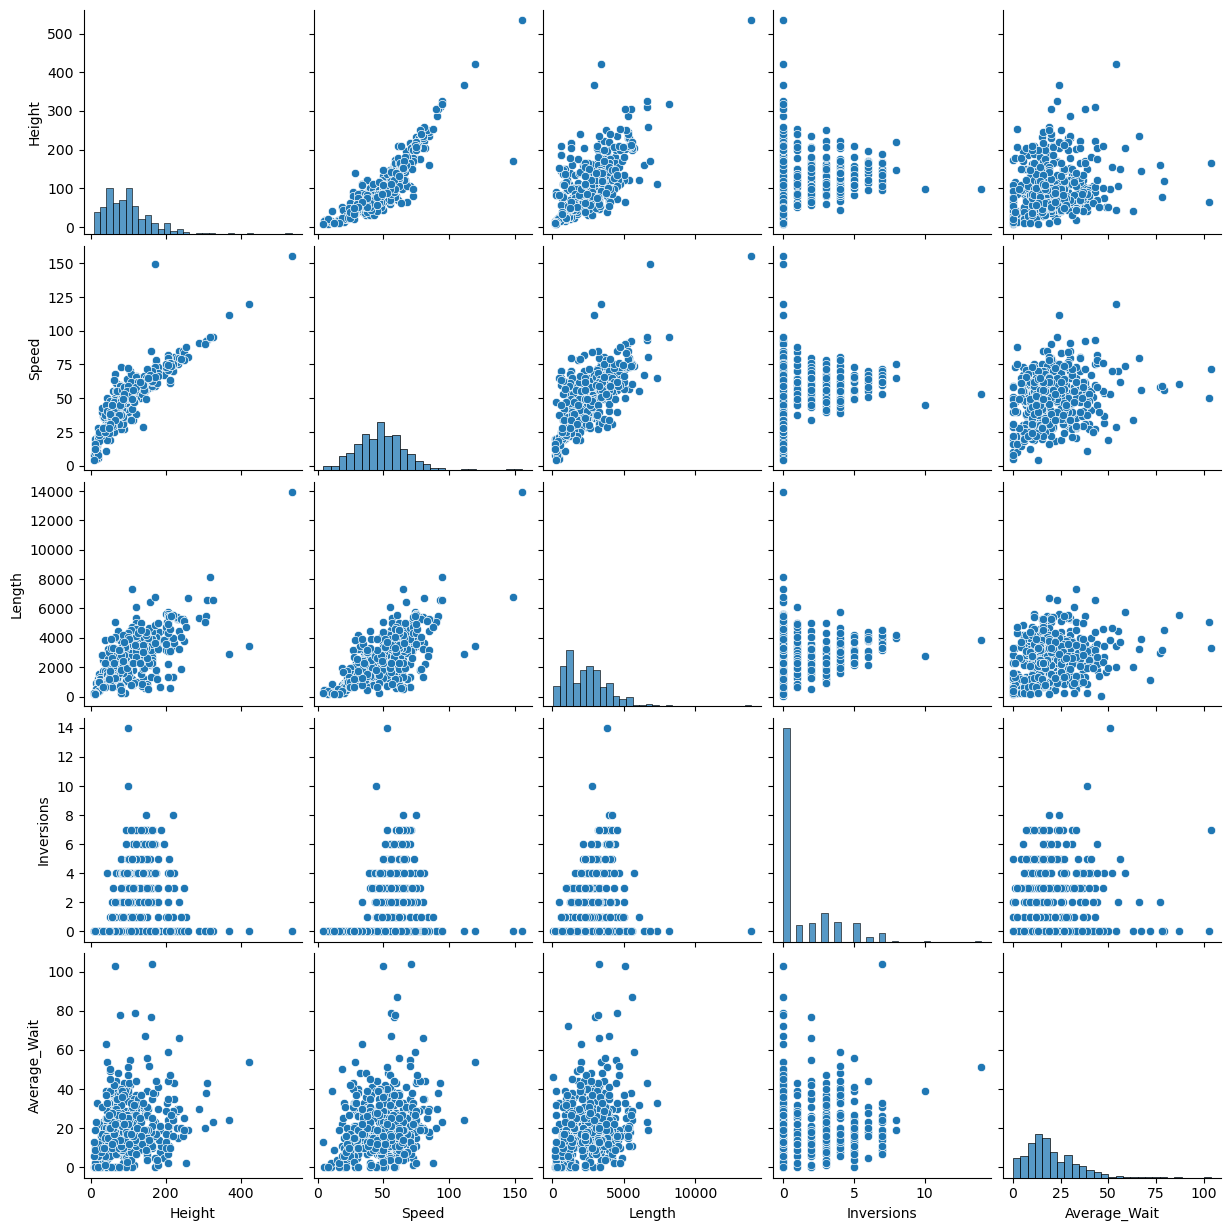

In [20]:
# Convert Inversions to float so seaborn treats it as a continuous variable
full_df['Inversions'] = full_df["Inversions"].astype(float)

# Generate pairwise relationship plots
fig = sns.pairplot(full_df[['Height', 'Speed', 'Length', 'Inversions', 'Average_Wait']])

Overall Insight: The strongest relationships in the dataset are between Height, Speed, and Length, indicating that these structural intensity variables scale together. In contrast, Inversions and Average Wait Time show weaker direct linear relationships, suggesting that ride popularity, as measured by wait time, may depend on multiple factors beyond just physical size or intensity.

Looking at just visualize relationships is not good enough evidence however. In the following sections we will use machine learning models to confirm this.

## Analysis #1 - Analyzing how a ride's relative thrill rank relates to average wait time


In order to adress sub question 1 of our hypothesis, we built a model to see if relative thrill ranking of a park can be used as a meaningful predictor of average wait time:

In [22]:
# Build model dataframe for Analysis #1 - Relative Thrill Rank vs Wait Time
model_df1 = full_df.copy()
model_df1 = model_df1.dropna(subset=['Thrill_Score', 'Relative_Thrill_Rank', 'Average_Wait'])
model_df1['Relative_Thrill_Rank'] = model_df1['Relative_Thrill_Rank'].astype(int)

# What we want to predict
y = model_df1['Average_Wait']

# Single predictor: relative thrill rank within park
X = model_df1[['Relative_Thrill_Rank']]

# Z-score numeric predictor
scaler = StandardScaler()
preprocessor = ColumnTransformer([
    ('zscore', scaler, ['Relative_Thrill_Rank'])
])

# Pipeline with SVR
pipe = Pipeline([
    ('make_features', preprocessor),
    ('regressor', SVR())
])

search_space = [
    {
        'regressor__kernel': ['linear'],
        'regressor__C': np.logspace(-3, 2, 11)
    },
    {
        'regressor__kernel': ['rbf'],
        'regressor__gamma': np.logspace(-3, 2, 11),
        'regressor__C': np.logspace(-3, 2, 11)
    },
]

# Split off 25% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=101)

# 10-fold cross validation
best_model1 = GridSearchCV(pipe, search_space, cv=10, verbose=1, scoring='r2')
%time best_model1.fit(X_train, y_train)

print(f"Best params:  {best_model1.best_params_}")
print(f"Best CV R²:   {best_model1.best_score_:.3f}")
print(f"Test R²:      {r2_score(y_test, best_model1.predict(X_test)):.3f}")

Fitting 10 folds for each of 132 candidates, totalling 1320 fits
CPU times: total: 18.2 s
Wall time: 20 s
Best params:  {'regressor__C': np.float64(100.0), 'regressor__kernel': 'linear'}
Best CV R²:   -0.050
Test R²:      -0.023


A negative R² means the model is performing worse than simply predicting the mean wait time every time, so relative thrill rank alone has essentially no predictive power over average wait.

## Analysis #2 - Assessing if longer rides lead to longer wait times
To adress sub question 2, we will examine ride length's influence on wait times. We want to answer whether roller coasters with longer ride lengths tend to have longer queue times. To control other factors, we isolated and only measured ride length independently. We answer this question by using a linear regression model with Ride_Length as the predictor and Wait_Time as the response variable. The linear regression model will reveal the direction and strength of the relationship between ride length and wait time.

Intercept: 13.257115574711662
Coefficient for Ride_Length: 0.002773113267762669


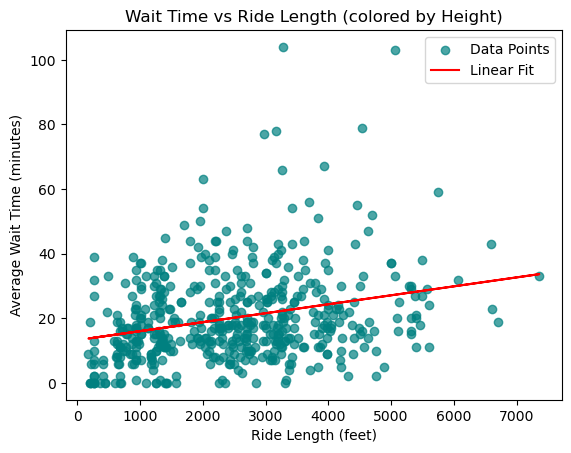

In [24]:
# Select relevant columns and drop missing values
df = full_df[['Length', 'Height', 'Average_Wait']].dropna()
df.rename(columns={'Length':'Ride_Length', 'Average_Wait':'Wait_Time'}, inplace=True)

# Predictor and response
X = df[['Ride_Length']]
y = df['Wait_Time']

# Fit linear regression
lr = LinearRegression()
lr.fit(X, y)

# Scatter plot of data
plt.scatter(df['Ride_Length'], df['Wait_Time'], alpha=0.7, color='teal', label='Data Points')

# Print coefficients
print(f"Intercept: {lr.intercept_}")
print(f"Coefficient for Ride_Length: {lr.coef_[0]}")

# creates plot
plt.plot(df['Ride_Length'], lr.predict(X), color='red', label='Linear Fit')
plt.title("Wait Time vs Ride Length (colored by Height)")
plt.xlabel("Ride Length (feet)")
plt.ylabel("Average Wait Time (minutes)")
plt.legend()
plt.show()

The linear regression indicates a weak positive relationship between ride length and average wait time. The slope of 0.00277 suggests that for every additional 1000 feet of ride length, predicted wait time increases by approximately 2.7 minutes. While this indicates a positive association, the slope is relatively small and the scatter plot shows substantial variability around the regression line. This suggests ride length alone explains only a small portion of the variation in wait times. Therefore, other factors such as ride popularity, thrill level, or intellectual property relevance likely play a more significant role in determining wait times.

## Analysis #3 - Average wait times across different ride audience categories (Kids, Family, Thrill) defined by thrill score

To answer sub question three: examining whether wait times differ across ride audience categories, we compare the distribution of average wait times across these groups using a one-way ANOVA, which tests whether the mean wait time is statistically the same across all three groups or whether at least one group differs meaningfully.

In [26]:
import statsmodels.api as sm

model_df3 = full_df.copy()
model_df3 = model_df3.dropna(subset=['Thrill_Score', 'Average_Wait'])

# One-way ANOVA
anova_result = sm.stats.anova_oneway(model_df3['Average_Wait'], groups=model_df3['Audience_Category'])
print(anova_result)

print()
if anova_result.pvalue < 0.05:
    print("Significant difference in wait times across audience categories (p < 0.05)")
else:
    print("No significant difference in wait times across audience categories")

# Group means for context
print("\nGroup means:")
print(model_df3.groupby('Audience_Category', observed=True)['Average_Wait'].agg(['mean', 'median', 'count']))

statistic = 15.79653158519424
pvalue = 4.0888743160549785e-07
df = (2.0, np.float64(208.80496004842388))
df_num = 2.0
df_denom = 208.80496004842388
nobs_t = 491.0
n_groups = 3
means = [20.21582734 13.69444444 22.08214286]
nobs = [139.  72. 280.]
vars_ = [164.41684913 107.4827856  214.95021761]
use_var = unequal
welch_correction = True
tuple = (np.float64(15.79653158519424), np.float64(4.0888743160549785e-07))

Significant difference in wait times across audience categories (p < 0.05)

Group means:
                        mean  median  count
Audience_Category                          
Family             20.215827    17.0    139
Kids               13.694444    11.5     72
Thrill             22.082143    19.0    280


The one-way ANOVA returned a significant result (p < 0.05), indicating that average wait times do differ across audience categories. 

Next we will use Tukey's post-hoc test to determine which group means are significantly different:


Tukey HSD Results:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
Family   Kids  -6.5214  0.003 -11.1645 -1.8782   True
Family Thrill   1.8663 0.3834  -1.4516  5.1842  False
  Kids Thrill   8.3877    0.0   4.1623 12.6131   True
-----------------------------------------------------


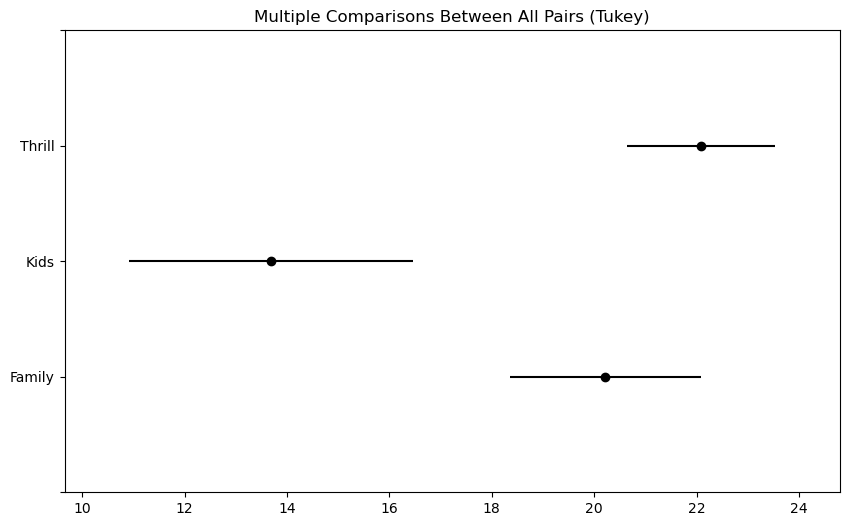

In [27]:
tukey_result = pairwise_tukeyhsd(endog=model_df3['Average_Wait'], groups=model_df3['Audience_Category'], alpha=0.05)
print("\nTukey HSD Results:")
print(tukey_result)
hsd_plot = tukey_result.plot_simultaneous()

Tukey's HSD post-hoc test reveals that the significant ANOVA result is driven by Kids rides differing from both Family and Thrill rides. Kids rides had significantly shorter wait times than Family rides (mean difference = 6.5 minutes, p = 0.003) and Thrill rides (mean difference = 8.4 minutes, p < 0.001). However, the difference between Family and Thrill rides was not significant (p = 0.383), suggesting that once a ride crosses out of the Kids category, audience type alone does not meaningfully separate wait times.

## Analysis #4 - Using Thrill characteristics to predict roller coaster wait times

We will now attempt to bring everything together by building a model using all of the thrill characteristics explored in previous sections: Thrill Score, Relative Thrill Rank, Length, Height, Speed, and Inversions to predict average wait time. If thrill characteristics are truly meaningful drivers of ride popularity, a model trained on all of these features combined should be able to predict wait times with reasonable accuracy. Conversely, if the model performs poorly even with all thrill variables included, it would strongly support our hypothesis that physical ride characteristics alone are insufficient to explain wait times, and that other factors such as IP, theming, and park context play a more dominant role.

In [29]:
# Build model dataframe with all thrill characteristics
model_df4 = full_df.copy()
model_df4 = model_df4.dropna(subset=['Height', 'Speed', 'Length', 'Inversions', 'Thrill_Score', 'Relative_Thrill_Rank', 'Average_Wait',])

# what we want to predict
y = model_df4['Average_Wait']

# all thrill characteristics as predictors
X = model_df4[['Height', 'Speed', 'Length', 'Inversions', 'Thrill_Score', 'Relative_Thrill_Rank']]

# z-score all numeric variables
scaler = StandardScaler()
preprocessor = ColumnTransformer([
    ('zscore', scaler, ['Height', 'Speed', 'Length', 'Inversions', 'Thrill_Score', 'Relative_Thrill_Rank'])
])

# Pipeline with SVR
pipe = Pipeline([('make_features', preprocessor),
                 ('regressor', SVR())])


search_space = [{'regressor__kernel': ['linear'],
                 'regressor__C': np.logspace(-3, 2, 11)
                },
                {'regressor__kernel': ['rbf'],
                 'regressor__gamma': np.logspace(-3, 2, 11),
                 'regressor__C': np.logspace(-3, 2, 11)
                },
                ]

# split off 25% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25, random_state=101)

# 10 fold cross validation 
best_model4 = GridSearchCV(pipe, search_space, cv=10, verbose=1, scoring='r2')
%time best_model4.fit(X_train, y_train)

print(f"Best params: {best_model4.best_params_}")
print(f"Best CV R²: {best_model4.best_score_:.3f}")
print(f"Test R²: {r2_score(y_test, best_model4.predict(X_test)):.3f}")

Fitting 10 folds for each of 132 candidates, totalling 1320 fits
CPU times: total: 20.4 s
Wall time: 22.5 s
Best params: {'regressor__C': np.float64(100.0), 'regressor__gamma': np.float64(0.01), 'regressor__kernel': 'rbf'}
Best CV R²: -0.007
Test R²: 0.058


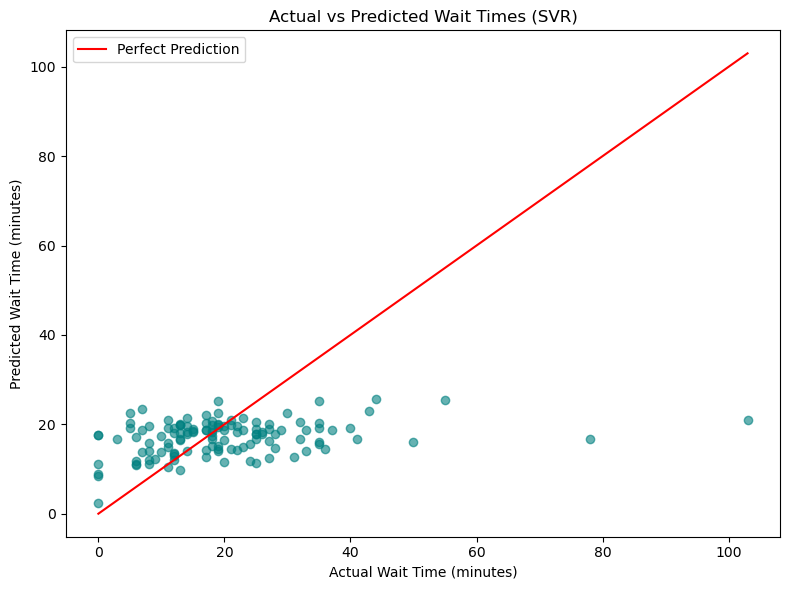

In [30]:
y_pred = best_model4.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', label='Perfect Prediction')
plt.title('Actual vs Predicted Wait Times (SVR)')
plt.xlabel('Actual Wait Time (minutes)')
plt.ylabel('Predicted Wait Time (minutes)')
plt.legend()
plt.tight_layout()
plt.show()

The residual plot and model metrics shows that despite combining all thrill characteristics that we identified in this project: Height, Speed, Length, Inversions, Thrill Score, and Relative Thrill Rank into a SVR model, the best CV R^2 achieved was just negative, meaning you are better off just guessing the mean.

From the residual plot we can see that predicted wait times cluster tightly between 10 and 25 minutes regardless of actual wait time. The model essentially learns to predict near the mean for every ride rather than capturing meaningful variation. Rides with actual wait times of 0 minutes and 75 minutes receive nearly identical predictions.

## Ethics


### Analysis

Some potential dataset bias is that the actual price to attend certain parks may be more expensive, and could impact the demographics on who can attend and how long they are able to stay at the park. This is why we are planning to compare the rides within their specific thrill category to measure rides against their similar counterparts to limit imbalanced class comparison. We are intentionally measuring major amusement park chains, which may affect demographics, as certain parks may be more expensive, and geographical location may impact who is able to attend and how long they are able to stay at the park. This is because specific regional parks may charge per-ride and would create more inconsistencies in wait times. 

### Modeling

We are optimizing our model for average wait time as a means to measure ride popularity. We may run into some issues as certain rides with larger capacities may be more popular, but could have lower wait times because the line moves faster as opposed to smaller capacity rides. We mitigate this by establishing that our models compare relative wait times against other rides in their respective categories.


## Discussion and Conclusion
Relative thrill rank within a park had essentially no predictive power over wait time, with the SVR model performing worse than simply guessing the mean. Ride length showed a weak positive relationship with wait time but explained very little variation on its own. The ANOVA found that Kids rides wait significantly less than Family and Thrill rides, though Family and Thrill rides were not meaningfully different from each other. When all thrill characteristics were combined into a single model, the R² reached only 0.042, confirming that physical ride characteristics are poor predictors of wait time overall.

Overall, the hypothesis that thrill characteristics would not significantly predict wait time was largely supported, with the full model explaining only 8% of wait time variation. The one nuance we did find is that kids rides do wait meaningfully less than other categories, but besides that, physical ride intensity has little effect on how long people are willing to queue.

Significant confounding variables likely explain much of the wait time variation this project could not capture. Two notable examples are intellectual property (IP) theming and cult classic status. A ride based on a beloved franchise may attract long lines regardless of its physical attributes, though quantifying IP strength is difficult since not all popular properties are tied to a single measurable metric like box office performance. Cult classics present an even harder problem, as their popularity is rooted in a park's history and reputation rather than any measurable characteristic. GhostRider at Knott's Berry Farm is a good example: despite a moderate thrill score of 65 and a middle-of-the-pack relative thrill rank of 4 within its park, it has the highest average wait at Knott's Berry Farm and one of the highest in the entire dataset at 79 minutes.

We can conclude from our results that ride characteristics such as height, speed, and intensity do not have a greater adverse affect on wait times in comparison to theme and intellectual property. This is significant because it challeneges the notion that more thrilling rides would generally have higher demand and wait times. This suggests that ride novelty and nostalgia play larger roles in atrraction wait times. Consumers of theme park attractions prefer a ride with a more culturally relatable experience, than a physically thrilling and exciting one. 

We were limited in that we were only able to look at data that was available. Some parks outside of the United States do not have readily available wait time data, leading to a somewhat systematic bias in the data we had to drop. Moreover, wait time data has only been available as long as theme parks have published wait time data on apps. Another thing to be noted was the average wait times varied depending on certain days of the week with larger crowds and general interest of the collective people that visit affecting wait times. Lastly operational maintenances for other rides may have had a factor into increasing wait times.
